Rod Ciombor <br>
4/20/26<br>
CIS-2532-NET01<br>
Dr. Sheikh Shamsuddin<br>
Week 10 Lab

<p><b><u>Question 1a</u></b></p>
<p>Machine Learning is a type of artificial intelligence that allows computer programs to learn and alter themselves without being given specific instructions.</p>

<p>Fundamentally, Machine Learning programs work by being fed sets of data, called training sets.  The program reads the data within these sets, then attempts to discover patterns, relationships, and commonalities among the values.  The program will take what it has discovered and use it to create a list of targets, which represent the list of possible categories each value can be assigned to.</p>

<p>Next, the ML program is fed what is called a training set, which is a smaller subset of the complete dataset, and should contain only data that the program has never seen before.  Because of this, it is common to divide a dataset into a larger training dataset and a smaller test dataset before training the program.</p>

<p>Once the program receives the test dataset, it will use one of a series of algorithms (the specific algorithm depends on the nature of the data and the problem it is trying to solve) to predict which target category (generated while training) each data point in the test dataset fits into.</p>

<p>Once this is completed, the program evaluates how many of its predictions were correct based on internal or external feedback, and uses that feedback to inform its future predictions.</p>

<p>This functionality allows ML programs to learn to identify certain data by its characteristics.  If it accurately identifies, say, a picture of an apple or a spam email, it will remember how to identify those things in the future.  Once it does so, it will not need to be taught what those things are again, although the more training sessions it completes and the more successful predictions it has, the more likely it is to make successful predictions in the future.</p>


<p><b><u>Question 1b</u></b></p>
<p>There are three broad categories of Machine Learning:  Supervised Learning, Unsupervised Learning, and Reinforcement Learning.</p>

<p><b>Supervised Learning</b></p>

<p>Supervised Learning is when a model is trained using a labeled dataset, meaning each input data is paired with a known correct output.  This allows the model to learn the relationship between inputs and outputs so it can predict the output for new data it has not yet seen.</p>

<p>One type of Supervised Learning is Classification.  Classification is when the model learns to assign inputs into predefined groups.  One common Classification algorithm is called Nearest Neighbor (or K-Nearest Neighbor).  This algorithm attempts to classify or predict a value based on what the closest datapoints are in a dataset (K is the number of datapoints it evaluates), the logic being that closer datapoints are likely to be grouped similarly.</p> 

<p>Another type of Supervised Learning is Regression.  Regression is when the model learns to predict a numeric value.  One common Regression algorithm is called Linear Regression.  This algorithm works by plotting a series of data points (usually in a scatterplot) and finding the best-fitting straight line through the plots.  It then uses the slope/rate of change of the line to extrapolate what a numerical value will be at any given time.</p>  

<p><b>Unsupervised Learning</b></p>

<p>Unsupervised Learning is when a model is given data without the labeled outputs and must find patterns, structure, and groupings on its own.  These methods are useful when you have large, non-homogeneous datasets with a mix of data types and values.</p>    

<p>One type of Unsupervised Learning is Clustering.  Clustering is the process of automatically grouping similar data points together without predefined labels based on their characteristics.  One common Clustering algorithm is known as K-means clustering.  This algorithm works by randomly placing a specified number of centroids (defined by K), assigning each datapoint to the nearest centroid based on its value or characteristics, then recalculating each centroid as the mean of its assigned points.  The process then repeats until the clusters stop changing.  This allows presumably similar data points to be grouped based on their values or characteristics, despite not having any labels or knowing much about them in advance.</p>

<p><b>Reinforcement Learning</b></p>

<p>Reinforcement Learning is when a model learns by interacting with an environment, taking actions, and receiving feedback in the form of rewards or penalties.  The model attempts to maximize its cumulative score or reward over time, and in doing so learns how to function and behave correctly.  There are many Reinforcement Learning algorithms, but they are beyond the scope of what we are learning in this course.</p>

<hr>


<b>Functions library contents</b><br>
Here is a list of the contents in <b>week10hw.py</b>
<br><br>

In [ ]:
# Author:       Rod Ciombor
# Date:         04/20/2026
# Instructor:   Dr. Sheikh Shamsuddin
# Class:        CIS-2532-NET01

import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
NYC_DATA = os.path.join(SCRIPT_DIR, 'ave_yearly_temp_nyc_1895-2017.csv')

def showYearlyHighTempTrend():
    #Load dataset
    nyc = pd.read_csv(NYC_DATA)
    #Rename columns
    nyc.columns = ['Date', 'Temperature', 'Anomaly']
    
    #Remove last two digits from dates
    nyc.Date = nyc.Date.floordiv(100)

    #Divide dataset into training and test datasets
    #Training is to train the model
    #Testing is to test the validity of the model
    X_train, X_test, y_train, y_test = train_test_split(
        nyc.Date.values.reshape(-1, 1), 
        nyc.Temperature.values, 
        random_state=11
    )

    #Create model/estimator
    linear_regression = LinearRegression()

    #Load both training sets (data = X, targets = Y) into estimator
    linear_regression.fit(X_train, y_train)

    #Set model parameters
    LinearRegression(
        copy_X=True,
        fit_intercept=True,
        n_jobs=None
    )

    #Anonymous function to predict slope
    predict = (lambda x: linear_regression.coef_ * x + linear_regression.intercept_)

    #Create scatterplot
    axes = sns.scatterplot(
        data=nyc, 
        x='Date', 
        y='Temperature', 
        hue='Temperature', 
        palette='winter', 
        legend=False
    )
    axes.set_ylim(10,70)
    axes.set_title("Average Yearly High Temperatures Over Time")

    #Create array of x-coordinates of regression line's start and end points
    x = np.array([nyc.Date.values.min(), nyc.Date.values.max()])

    #Create array of predicted y-coordinate values
    y = predict(x)

    #Plot the line
    line = plt.plot(x, y)

    #Show the plot
    plt.show()

def showJanuaryHighTempTrend():
    # Load dataset
    nyc = pd.read_csv(NYC_DATA)

    # Rename columns to reflect meaning
    nyc.columns = ['Date', 'JanHighTemp', 'Anomaly']

    # Convert Date to year only (removes last two digits if formatted YYYYMM)
    nyc.Date = nyc.Date.floordiv(100)

    # Split into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        nyc.Date.values.reshape(-1, 1),
        nyc.JanHighTemp.values,
        random_state=11
    )

    # Create and train model
    linear_regression = LinearRegression()
    linear_regression.fit(X_train, y_train)

    # Prediction function (y = mx + b)
    predict = lambda x: linear_regression.coef_ * x + linear_regression.intercept_

    # Scatterplot: January average high temperatures over time
    '''
    axes = sns.scatterplot(
        data=nyc,
        x='Date',
        y='JanHighTemp',
        color='blue',
        legend=False
    )
    '''

    axes = sns.scatterplot(
        data=nyc, 
        x='Date', 
        y='JanHighTemp', 
        hue='JanHighTemp', 
        palette='winter', 
        legend=False
    )

    axes.set_title("Average January High Temperatures Over Time")
    axes.set_ylabel("Temperature")
    axes.set_xlabel("Year")
    axes.set_ylim(10, 70)

    # Regression line
    x = np.array([nyc.Date.min(), nyc.Date.max()])
    y = predict(x)
    plt.plot(x, y)

    plt.show()

def caliHousingPairPlot(numFeatures):

    # numFeatures indicates how many features from the Cali Housing Dataset to display
    
    # Load dataset
    cali = fetch_california_housing()

    pd.set_option('display.max_columns', 10)
    pd.set_option('display.width', None)

    # Create DataFrame
    cali_df = pd.DataFrame(cali.data, columns=cali.feature_names)

    # Add target (median house value)
    cali_df['MedHouseValue'] = cali.target

    # Create bins for a pseudo "category" (for hue)
    # Don't want hundreds of different hue values
    cali_df['PriceCategory'] = pd.cut(
        cali_df['MedHouseValue'],
        bins=3,
        labels=['Low', 'Medium', 'High']
    )

    # Seaborn styling
    sns.set_theme(font_scale=1.1)
    sns.set_style('whitegrid')

    # Create Pairplot
    grid = sns.pairplot(
        data=cali_df,
        vars=cali_df.columns[0:numFeatures],  # first 4 numeric features
        hue='PriceCategory'
    )

    #Show plot
    plt.show()


<b>Question 15.3 Output</b><br>
Here is the output for question 15.3.  I set the function up to accept the number of feature columns that appear as an argument, but went with four for this example (since that is what we did for the Iris dataset example).<br><br>The Matplotlib controls allow you to zoom in on an area or cluster that you draw a rectangle around with your mouse, while the panning control allows you to slide the chart right or left.  This is beneficial if you have huge charts like the California Pricing Data pair plot.
<br><br>

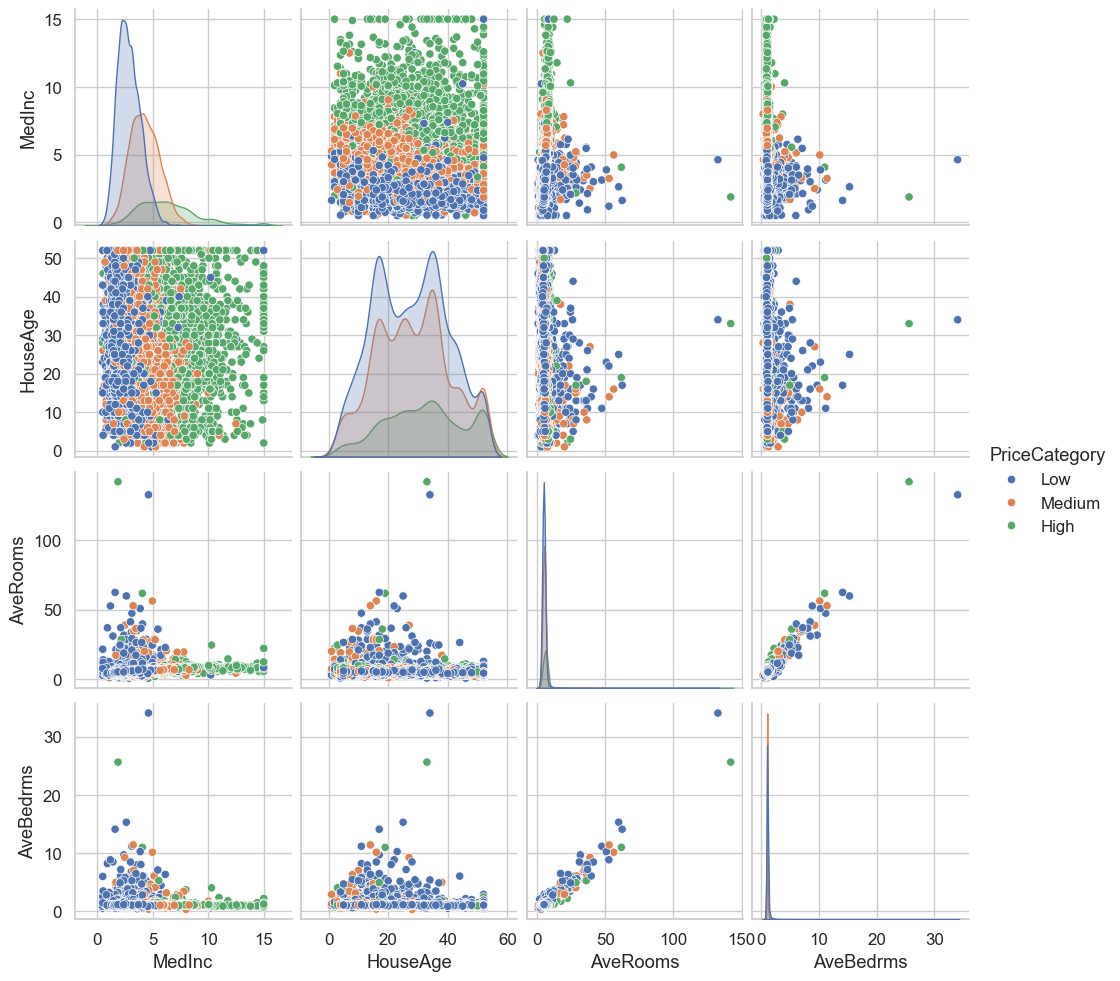

In [1]:
import week10hw as lib
lib.caliHousingPairPlot(4)

<b>Question 15.6 Output: Part 1</b><br>
Here is the output for question 15.6, showing the trend of the change in yearly average high temperature over time
<br><br>

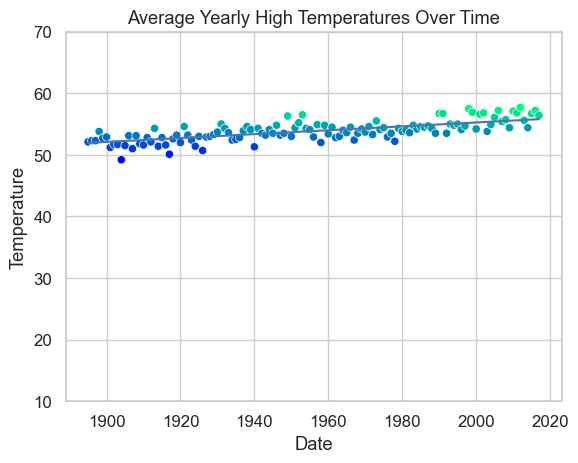

In [2]:
import week10hw as lib
lib.showYearlyHighTempTrend()

<b>Question 15.4 Output: Part 2</b><br>
Here is the output for question 15.4, showing the trend of the change in average high temperature for January over time<br><br>
What I noticed is that the trend for January follows the annual trend pretty closely, with average temperatures gradually trending upward over time...increasing by about 4 degrees.  It also shows how the highest temperatures in the range, represented by the light green dots, are all clustered after the year 2000.  This suggests that while the average temperature is increasing gradually over time, the most extreme high temperatures have occurred within the last 20 years.<br><br>
The two charts are not identical, however.  When I zoomed in on the January Temperature chart, I could see that the plots were not as tightly fitted to the regression line as the annual average chart, suggesting more variance in the temperatures.
<br><br>

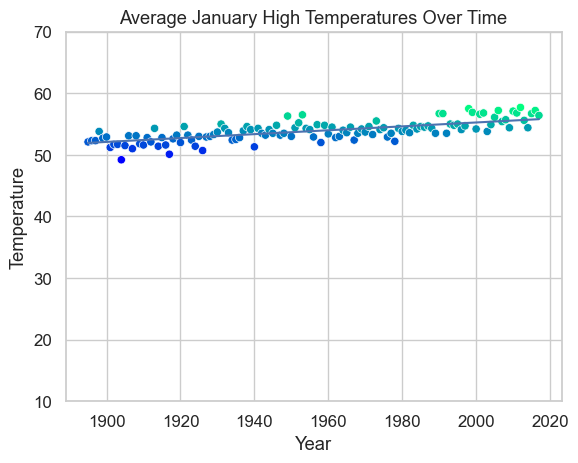

In [5]:
import week10hw as lib
lib.showJanuaryHighTempTrend()